In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
# No longer need LinearRegression for normal equation implementation
# from sklearn.linear_model import LinearRegression

x1 = np.array([1, 2, 3])
y1 = np.array([2, 4, 6])
y2 = np.array([3, 5, 7])

In [ ]:
# Reshape x1 for sklearn (it expects a 2D array: n_samples, n_features)
X = x1.reshape(-1, 1)


In [ ]:
# Combine y1 and y2 into a single target array for multivariate regression
Y = np.column_stack((y1, y2))


In [ ]:
# Implement the Normal Equation
# Add a bias (intercept) term to X
X_b = np.c_[np.ones((X.shape[0], 1)), X] # Add column of ones

In [ ]:

# Calculate theta using the Normal Equation: theta = (X_b.T @ X_b)^-1 @ X_b.T @ Y
theta = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ Y

In [ ]:

# Extract intercept and coefficients
intercept = theta[0]
coefficients = theta[1:]

In [ ]:
# Make predictions using the calculated theta
Y_pred = X_b @ theta

In [ ]:
# Print the regression equation coefficients and intercept
print("Multivariate Regression Equation (using Normal Equation):")
print(f"Coefficients: {coefficients}")
print(f"Intercept: {intercept}")


Multivariate Regression Equation (using Normal Equation):
Coefficients: [[2. 2.]]
Intercept: [-3.55271368e-15  1.00000000e+00]


In [ ]:
# Perform error metrics for each output variable
print("\nError Metrics:")
for i, col_name in enumerate(['y1', 'y2']):
    print(f"\nMetrics for {col_name}:")
    mae = mean_absolute_error(Y[:, i], Y_pred[:, i])
    mse = mean_squared_error(Y[:, i], Y_pred[:, i])
    rmse = np.sqrt(mse)
    r2 = r2_score(Y[:, i], Y_pred[:, i])
    print(f"  Mean Absolute Error (MAE): {mae:.2f}")
    print(f"  Mean Squared Error (MSE): {mse:.2f}")
    print(f"  R-squared (R2): {r2:.2f}")
    print(f"  Root Mean Squared Error (RMSE): {rmse:.2f}")


Error Metrics:

Metrics for y1:
  Mean Absolute Error (MAE): 0.00
  Mean Squared Error (MSE): 0.00
  R-squared (R2): 1.00
  Root Mean Squared Error (RMSE): 0.00

Metrics for y2:
  Mean Absolute Error (MAE): 0.00
  Mean Squared Error (MSE): 0.00
  R-squared (R2): 1.00
  Root Mean Squared Error (RMSE): 0.00


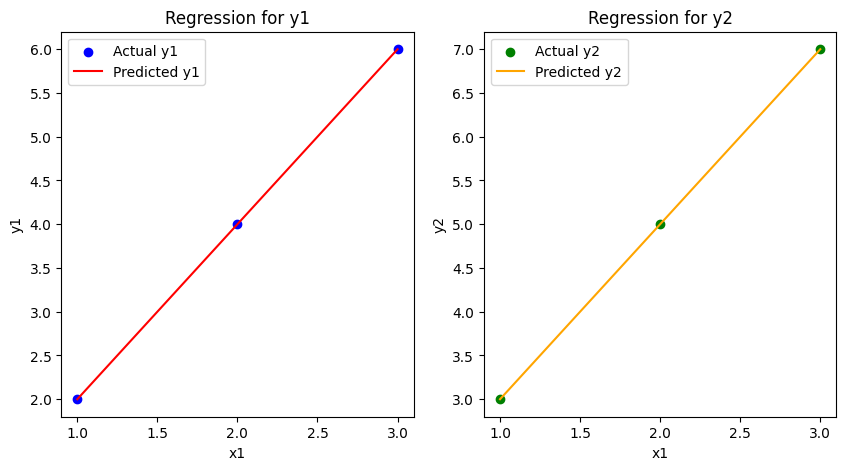

In [ ]:
# Optional: Plotting the results
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.scatter(X, Y[:, 0], color='blue', label='Actual y1')
plt.plot(X, Y_pred[:, 0], color='red', label='Predicted y1')
plt.title('Regression for y1')
plt.xlabel('x1')
plt.ylabel('y1')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(X, Y[:, 1], color='green', label='Actual y2')
plt.plot(X, Y_pred[:, 1], color='orange', label='Predicted y2')
plt.title('Regression for y2')
plt.xlabel('x1')
plt.ylabel('y2')
plt.legend()

In [ ]:


plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [ ]:
# Ridge Regression
# Question 1

import numpy as np

# Input data
x = np.array([[1, 2],
              [1, 3],
              [1, 4]])

y = np.array([[1],
              [2],
              [3]])

# Matrix calculations
x_t_mul_x = np.dot(x.T, x)
x_t_mul_y = np.dot(x.T, y)

alpha = 1
lambda_mul_i = alpha * np.array([[0, 0],
                                 [0, 1]])

x_t_mul_x_plus_lambda_mul_i = x_t_mul_x + lambda_mul_i

print(x_t_mul_x_plus_lambda_mul_i)

x_t_mul_x_plus_lambda_mul_i_inv = np.linalg.inv(x_t_mul_x_plus_lambda_mul_i)
print(x_t_mul_x_plus_lambda_mul_i_inv)

y_pred = np.dot(x_t_mul_x_plus_lambda_mul_i_inv, x_t_mul_y)
print(y_pred)

print(f"The regression equation is : y_pred={y_pred[0]} + {y_pred[1]}x")


# ------------------------------------
# Ridge Regression
# Question 2

import numpy as np

# Input data
x = np.array([[1, 1, 2],
              [1, 2, 3],
              [1, 3, 4]])

y = np.array([[1],
              [2],
              [3]])

print(x)

# Matrix calculations
x_t_mul_x = np.dot(x.T, x)
x_t_mul_y = np.dot(x.T, y)

alpha = 1
lambda_mul_i = alpha * np.array([[1, 0, 0],
                                 [0, 1, 0],
                                 [0, 0, 1]])

x_t_mul_x_plus_lambda_mul_i = x_t_mul_x + lambda_mul_i

print(x_t_mul_x_plus_lambda_mul_i)

x_t_mul_x_plus_lambda_mul_i_inv = np.linalg.inv(x_t_mul_x_plus_lambda_mul_i)
print(x_t_mul_x_plus_lambda_mul_i_inv)

y_pred = np.dot(x_t_mul_x_plus_lambda_mul_i_inv, x_t_mul_y)
print(y_pred)

print(f"The regression equation is : y_pred={y_pred[0]} + {y_pred[1]}x1 + {y_pred[2]}x2")